In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import minimize
import cvxpy as cp

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy import stats
from itertools import combinations



# Preparation - work from GWP 2

## 1. Reuse the same dataset for training

In [ ]:
# clean and prepar data

tickers =['AAPL','MSFT','GOOG','AMZN','NVDA']

start_date = "2023-01-01"
end_date = "2023-06-30"

portfolio_raw = yf.download(tickers, start=start_date, end=end_date)

/tmp/ipython-input-1869899306.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_raw = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


In [ ]:
portfolio_data = portfolio_raw.copy()
portfolio_data = portfolio_data['Close']
portfolio_data.columns = tickers
portfolio_data = portfolio_data.apply(pd.to_numeric, errors='coerce')
portfolio_daily_returns = portfolio_data.pct_change()
portfolio_daily_returns= portfolio_daily_returns.dropna()

In [ ]:
portfolio_daily_returns.head()

,AAPL,MSFT,GOOG,AMZN,NVDA
Date,,,,,
2023-01-04,0.010314,-0.007924,-0.011037,-0.043743,0.030318
2023-01-05,-0.010605,-0.023726,-0.021869,-0.029638,-0.032816
2023-01-06,0.036794,0.035611,0.016019,0.011785,0.041640
2023-01-09,0.004089,0.014870,0.007259,0.009736,0.051753
2023-01-10,0.004456,0.028732,0.004955,0.007617,0.017981


In [ ]:
portfolio_daily_returns.describe()

,AAPL,MSFT,GOOG,AMZN,NVDA
count,122.000000,122.000000,122.000000,122.000000,122.000000
mean,0.003523,0.003524,0.002612,0.002951,0.009251
std,0.012998,0.022400,0.021243,0.018027,0.036537
min,-0.026680,-0.084315,-0.074417,-0.043743,-0.059072
25%,-0.005627,-0.010838,-0.009851,-0.007890,-0.013848
50%,0.002308,0.001608,0.000982,0.001115,0.006348
75%,0.011064,0.018137,0.015922,0.012911,0.025964
max,0.046927,0.073799,0.072661,0.072435,0.243697



1.3. Covariance Matrix of Fama-French (5) Factors:
            AAPL        MSFT        GOOG         AMZN        NVDA
AAPL  253.912065  168.811833  170.673669   527.191555  115.731933
MSFT  168.811833  139.613901  132.240465   368.227315   83.663345
GOOG  170.673669  132.240465  141.175946   378.535790   81.461229
AMZN  527.191555  368.227315  378.535790  1150.260084  247.369735
NVDA  115.731933   83.663345   81.461229   247.369735   58.732354


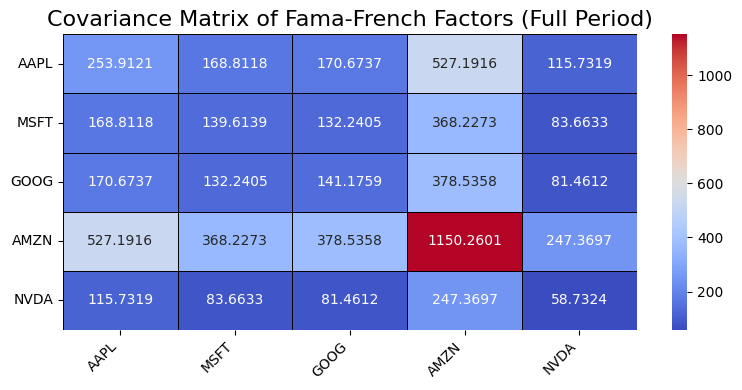

In [ ]:
# Covariance Matrix
print("\n1.3. Covariance Matrix of Fama-French (5) Factors:")
covariance_matrix_full = portfolio_data.cov()
print(covariance_matrix_full.round(8))

plt.figure(figsize=(8,4 ))
sns.heatmap(covariance_matrix_full, annot=True, cmap='coolwarm', fmt=".4f", linewidths=.5, linecolor='black')
plt.title('Covariance Matrix of Fama-French Factors (Full Period)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("Selected tickers:", portfolio_daily_returns.columns.tolist())
print("Shape of return data:", portfolio_daily_returns.shape)
portfolio_daily_returns.cov()

Selected tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
Shape of return data: (122, 5)


,AAPL,MSFT,GOOG,AMZN,NVDA
AAPL,0.000169,0.000161,0.000168,0.000136,0.000197
MSFT,0.000161,0.000502,0.000304,0.000260,0.000243
GOOG,0.000168,0.000304,0.000451,0.000244,0.000274
AMZN,0.000136,0.000260,0.000244,0.000325,0.000352
NVDA,0.000197,0.000243,0.000274,0.000352,0.001335


In [ ]:
# Calculate risk-free rate during the period
rf = yf.download('^TNX', start=start_date, end=end_date)
rf_rate = rf['Close'].mean().item()

/tmp/ipython-input-2622429574.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rf = yf.download('^TNX', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
rf_annual = rf_rate/100  # Convert from percent to decimal
rf_daily = rf_annual / 252
print(f"Risk-free rate (annual): {rf_annual:.2%}")
print(f"Risk-free rate (daily): {rf_daily:.2%}")

Risk-free rate (annual): 3.62%
Risk-free rate (daily): 0.01%


## 2. Best Portfolio from GWP2 - Black-Litterman

In [ ]:
# Step 1: Calculate expected returns and covariance matrix
mean_returns = portfolio_daily_returns.mean()
cov_matrix = portfolio_daily_returns.cov()

# Step 2: Set constraints and bounds
num_assets = len(mean_returns)
bounds = tuple((0, 1) for _ in range(num_assets))  # No shorting
#min_weight = 0.05 # minimum weight 5%
constraints = [{'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}]  # Weights sum to 1
np.random.seed(123)

In [ ]:
# Step 3: Define functions for portfolio metrics

def portfolio_performance(weights, mean_returns, cov_matrix):
    #Compute expected portfolio return and volatility (daily)
    ret = np.dot(weights, mean_returns) # Daily mean return
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) # Daily volatility
    return ret, vol

def negative_return(weights):
    return -portfolio_performance(weights, mean_returns, cov_matrix)[0]

def negative_sharpe(weights):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = (ret - rf_daily) / vol
    return -sharpe

def minimize_volatility(weights):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]


Original Expected Returns (pi): [0.0035226  0.00352432 0.00261212 0.0029511  0.00925091]
Black-Litterman Adjusted Returns (pi_bl): [0.00413272 0.00445717 0.0033067  0.00403046 0.01334776]

--- Black-Litterman Optimal Portfolio (Max Sharpe) ---
AAPL: 0.6437
MSFT: 0.0107
GOOG: 0.0000
AMZN: 0.0000
NVDA: 0.3456

Expected Annualized Return: 184.48%
Expected Annualized Volatility: 28.44%
Sharpe Ratio: 6.3592


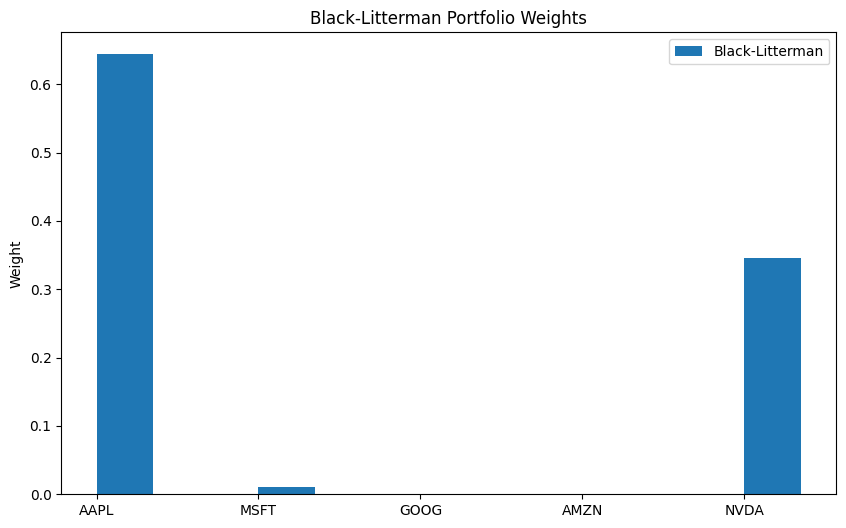

In [ ]:
# Step 4: Black-Litterman Model
# Find recent news/headlines to form views.
#News1: Microsoft invests billions more dollars in OpenAI, extends partnership
#News2: “Nvidia shares soar nearly 30% as sales forecast jumps and AI booms”
#News3: Apple second quarter revenue of $94.8 billion down 3% year over year, and all-time high record for service revenue.

# Assumptions:
# We use an equal-weighted portfolio as the market equilibrium prior (pi).
pi = portfolio_daily_returns.mean().values
tau = 0.05  # A scalar parameter representing the uncertainty of the prior.

# Views setup
#View1: Microsoft will outperform Google in the next quarter by around 6% due to its increasing investment
#View2: View: Nicidia will continue to grow for about 20% with AI bloom
#View3: Apple will outperform Amazon (in service relatives revenue) for about 3%.

P = np.array([
    [0, 1, -1, 0, 0],  # MSFT will outperform GOOG
    [0, 0, 0, 0, 1],   # NVDA will continue to grow for 20%
    [1, 0, 0, -1, 0]   # AAPL will outperform AMZN
])
q = np.array([0.06, 0.2,0.03]) # MSFT-GOOG difference, NVDA absolute return, AAPL-AMZN difference

# Uncertainty matrix of views (Omega)
# Diagonal elements represent the variance of the error term for each view.
# We will use a simple, small diagonal matrix for this example.
omega = np.diag([0.003, 0.003,0.009]) #high confidence in MSFT and NVDA performance, and medium-high confidence in AAPL performance
cov = cov_matrix.values

# Black-Litterman formula implementation
inv_tau_cov = np.linalg.inv(tau * cov)
inv_omega = np.linalg.inv(omega)

middle = np.linalg.inv(inv_tau_cov + P.T @ inv_omega @ P)
rhs = inv_tau_cov @ pi + P.T @ inv_omega @ q
pi_bl = middle @ rhs

print("\nOriginal Expected Returns (pi):", pi)
print("Black-Litterman Adjusted Returns (pi_bl):", pi_bl)


#new Sharpe ratio function for Black-Litterman
def negative_sharpe_bl(weights, bl_returns, cov_matrix, rf_daily):
    ret = np.dot(weights, bl_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    if vol == 0:
        return 0
    sharpe = (ret - rf_daily) / vol
    return -sharpe

#Run the optimization using the BL returns
init_guess_bl = num_assets * [1 / num_assets]
optimized_bl = minimize(
    negative_sharpe_bl,
    init_guess_bl,
    args=(pi_bl, cov, rf_daily),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

#Extract and print Black-Litterman results
opt_weights_bl = optimized_bl.x
expected_return_bl, expected_vol_bl = portfolio_performance(opt_weights_bl, pi_bl, cov)
bl_ret = expected_return_bl * 252
bl_vol = expected_vol_bl * np.sqrt(252)
bl_sharpe = (bl_ret - rf_annual) / bl_vol

print("\n--- Black-Litterman Optimal Portfolio (Max Sharpe) ---")
for ticker, weight in zip(tickers, opt_weights_bl):
    print(f"{ticker}: {weight:.4f}")
print(f"\nExpected Annualized Return: {bl_ret:.2%}")
print(f"Expected Annualized Volatility: {bl_vol:.2%}")
print(f"Sharpe Ratio: {bl_sharpe:.4f}")


# Plot Markowitz vs Black-Litterman weights
plt.figure(figsize=(10, 6))
x = np.arange(num_assets)
width = 0.35
plt.bar(x + width/2, opt_weights_bl, width, label='Black-Litterman')
plt.xticks(x, tickers)
plt.ylabel("Weight")
plt.title("Black-Litterman Portfolio Weights")
plt.legend()
plt.show()

# Step 2
Students work together to apply these to the group’s portfolio from GWP2. Specifically, they will pick the best portfolio from GWP2. The ‘best’ portfolio will prove to have a superior risk reward relationship. They prepare a document explaining the merits of applying one, two, or all of these improvements to the current portfolio.


# 1. Denoising

In [ ]:
# 1.1 functions for denoising
def cov_to_corr(cov):
   # Derive the correlation matrix from a covariance matrix
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    corr[corr < -1], corr[corr > 1] = -1, 1  #for numerical errors
    return corr

def corr_to_cov(corr, std):
    return corr * np.outer(std, std)

def marcenko_pastur_denoise(cov_matrix, tn_relation):
    corr = cov_to_corr(cov_matrix)
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)

    lambda_max = (1 + np.sqrt(1 / tn_relation))**2

    # Replace noisy eigenvalues with their mean
    signal = eigenvalues > lambda_max
    avg_noise = eigenvalues[~signal].mean() if any(~signal) else 0
    eigenvalues_denoised = np.where(signal, eigenvalues, avg_noise)

    # Reconstruct denoised correlation matrix
    corr_denoised = eigenvectors @ np.diag(eigenvalues_denoised) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1.0)

    original_std = np.sqrt(np.diag(cov_matrix))
    cov_denoised = corr_to_cov(corr_denoised, original_std)

    return cov_denoised


In [ ]:
def calculate_metrics(weights, returns, cov_matrix, rf_annual, data=None):
    ret, vol = portfolio_performance(weights, returns, cov_matrix)
    annual_ret = ret #* 252
    annual_vol = vol * np.sqrt(252)
    sharpe = (annual_ret - rf_annual) / annual_vol if annual_vol > 0 else 0

    # Calculate Expected Shortfall (CVaR) at 95% confidence
    if data is not None:
        portfolio_returns = (data * weights).sum(axis=1)
        var_95 = np.percentile(portfolio_returns, 5)
        es_95 = portfolio_returns[portfolio_returns <= var_95].mean()

        # Calculate Maximum Drawdown
        cumulative_returns = (1 + portfolio_returns).cumprod()
        peak = cumulative_returns.expanding(min_periods=1).max()
        drawdown = (cumulative_returns - peak) / peak
        max_drawdown = drawdown.min()
    else:
        es_95 = np.nan
        max_drawdown = np.nan

    return {
        'weights': weights,
        'expected_return': annual_ret,
        'expected_volatility': annual_vol,
        'sharpe_ratio': sharpe,
        'expected_shortfall_95': es_95,
        'max_drawdown': max_drawdown
    }

In [ ]:
# 1.2 Apply denoising to BL model
T, N = portfolio_daily_returns.shape
tn_relation = T / N
cov_denoised = marcenko_pastur_denoise(cov_matrix, tn_relation)

In [ ]:
inv_tau_cov_denoised = np.linalg.inv(tau * cov_denoised)
middle_denoised = np.linalg.inv(inv_tau_cov_denoised + P.T @ inv_omega @ P)
rhs_denoised = inv_tau_cov_denoised @ pi + P.T @ inv_omega @ q
pi_bl_denoised = middle_denoised @ rhs_denoised

# Optimize with denoised covariance
optimized_bl_denoised = minimize(
    negative_sharpe_bl,
    init_guess_bl,
    args=(pi_bl_denoised, cov_denoised, rf_daily),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_weights_denoised = optimized_bl_denoised.x

# 2. Clustering

In [ ]:
# ONC (Optimal Number of Clusters)
# 2.1 functions for clustering
def corr_to_dist(corr):
    """Convert correlation matrix to distance matrix."""
    return np.sqrt(0.5 * (1 - corr))

def cluster_score(cluster_indices, corr_matrix):
    """ONC score: within-cluster correlation - global correlation."""
    if len(cluster_indices) <= 1:
        return 0
    sub_corr = corr_matrix[np.ix_(cluster_indices, cluster_indices)]
    within = np.mean(sub_corr)
    across = np.mean(corr_matrix)
    return within - across

def recursive_bipartition(cluster_indices, corr_matrix, max_clusters, clusters, current_cluster_id):
    """Recursively split cluster if it improves ONC score."""
    if len(cluster_indices) <= 2 or len(clusters) >= max_clusters:
        clusters[current_cluster_id] = cluster_indices
        return

    sub_corr = corr_matrix[np.ix_(cluster_indices, cluster_indices)]
    dist_matrix = corr_to_dist(sub_corr)
    condensed = squareform(dist_matrix, checks=False)

    linkage_matrix = linkage(condensed, method="ward")
    sub_clusters = fcluster(linkage_matrix, 2, criterion="maxclust")

    cluster1 = [cluster_indices[i] for i in range(len(cluster_indices)) if sub_clusters[i] == 1]
    cluster2 = [cluster_indices[i] for i in range(len(cluster_indices)) if sub_clusters[i] == 2]

    parent_score = cluster_score(cluster_indices, corr_matrix)
    child_score = (cluster_score(cluster1, corr_matrix) + cluster_score(cluster2, corr_matrix)) / 2

    if child_score > parent_score:  # accept split
        recursive_bipartition(cluster1, corr_matrix, max_clusters, clusters, current_cluster_id)
        new_cluster_id = max(clusters.keys()) + 1
        recursive_bipartition(cluster2, corr_matrix, max_clusters, clusters, new_cluster_id)
    else:  # stop splitting
        clusters[current_cluster_id] = cluster_indices

def get_optimal_clusters(corr_matrix, max_num_clusters=10):
    """Main ONC wrapper."""
    n_assets = corr_matrix.shape[0]
    clusters = {}
    recursive_bipartition(list(range(n_assets)), corr_matrix, max_num_clusters, clusters, current_cluster_id=1)
    labels = np.zeros(n_assets, dtype=int)
    for cluster_id, indices in clusters.items():
        for idx in indices:
            labels[idx] = cluster_id
    return labels


# Hierarchical Optimization
def hierarchical_optimization(returns_df, mu, cov_matrix, corr_matrix, max_num_clusters=5):
    # Step 1: Cluster assets with ONC
    clusters = get_optimal_clusters(corr_matrix, max_num_clusters)
    cluster_assignments = {}
    for asset, cluster_id in zip(returns_df.columns, clusters):
        cluster_assignments.setdefault(cluster_id, []).append(asset)

    print("ONC Cluster Assignments:")
    for cid, assets in cluster_assignments.items():
        print(f"Cluster {cid}: {assets}")

    final_weights = np.zeros(len(returns_df.columns))
    cluster_portfolios = {}

    # Intra-cluster optimization
    for cluster_id, assets_in_cluster in cluster_assignments.items():
        cluster_returns = returns_df[assets_in_cluster]
        cluster_mu = cluster_returns.mean().values
        indices_in_original = [returns_df.columns.get_loc(asset) for asset in assets_in_cluster]
        cluster_cov = cov_matrix[np.ix_(indices_in_original, indices_in_original)]

        n_assets_in_cluster = len(assets_in_cluster)
        cluster_bounds = tuple((0, 1) for i in range(n_assets_in_cluster))
        cluster_constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        cluster_initial_guess = n_assets_in_cluster * [1. / n_assets_in_cluster]

        def negative_sharpe_simple(weights, mu, cov_matrix):
            ret = np.dot(weights, mu)
            vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
            return -ret/vol if vol > 0 else 0

        result = minimize(negative_sharpe_simple, cluster_initial_guess,
                         args=(cluster_mu, cluster_cov),
                         method='SLSQP', bounds=cluster_bounds, constraints=cluster_constraints)

        cluster_portfolios[cluster_id] = {
            'assets': assets_in_cluster,
            'weights': result.x,
            'indices': indices_in_original
        }

    # Inter-cluster optimization
    cluster_returns_list = []
    cluster_ids = list(cluster_portfolios.keys())

    for cluster_id in cluster_ids:
        portfolio_info = cluster_portfolios[cluster_id]
        assets = portfolio_info['assets']
        weights = portfolio_info['weights']
        cluster_portfolio_return = (returns_df[assets] * weights).sum(axis=1)
        cluster_returns_list.append(cluster_portfolio_return)

    cluster_returns_df = pd.concat(cluster_returns_list, axis=1)
    cluster_mu = cluster_returns_df.mean().values
    cluster_cov = cluster_returns_df.cov().values
    n_clusters = len(cluster_mu)

    cluster_bounds = tuple((0, 1) for i in range(n_clusters))
    cluster_constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    cluster_initial_guess = n_clusters * [1. / n_clusters]

    result = minimize(negative_sharpe_simple, cluster_initial_guess,
                     args=(cluster_mu, cluster_cov),
                     method='SLSQP', bounds=cluster_bounds, constraints=cluster_constraints)

    optimal_cluster_weights = result.x

    # Final weights = inter * intra
    for i, cluster_id in enumerate(cluster_ids):
        intra_weights = cluster_portfolios[cluster_id]['weights']
        asset_indices = cluster_portfolios[cluster_id]['indices']
        for j, asset_index in enumerate(asset_indices):
            final_weights[asset_index] = optimal_cluster_weights[i] * intra_weights[j]

    return final_weights / np.sum(final_weights)


In [ ]:
# 2.2 Apply clustering

# to Base_BL model
corr_base = cov_to_corr(cov_matrix.values)

opt_weights_clustered = hierarchical_optimization(
    portfolio_daily_returns,
    pi,
    cov_matrix.values,
    corr_base,
    max_num_clusters=5
)

# 2.3 Calculate metrics for clustered model
metrics_clustered = calculate_metrics(opt_weights_clustered, pi, cov_matrix.values, rf_annual, portfolio_daily_returns)

print("\n--- Black-Litterman With Denoising and Clustering ---")
for ticker, weight in zip(tickers, opt_weights_clustered):
    print(f"{ticker}: {weight:.4f}")

print(f"Expected Annualized Return: {metrics_clustered['expected_return']:.2%}")
print(f"Expected Annualized Volatility: {metrics_clustered['expected_volatility']:.2%}")
print(f"Sharpe Ratio: {metrics_clustered['sharpe_ratio']:.4f}")
print(f"Expected Shortfall (95%): {metrics_clustered['expected_shortfall_95']:.4f}")
print(f"Maximum Drawdown: {metrics_clustered['max_drawdown']:.2%}")

ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']

--- Black-Litterman With Denoising and Clustering ---
AAPL: 0.7453
MSFT: 0.0132
GOOG: 0.0000
AMZN: 0.0106
NVDA: 0.2309
Expected Annualized Return: 0.48%
Expected Annualized Volatility: 24.66%
Sharpe Ratio: -0.1273
Expected Shortfall (95%): -0.0203
Maximum Drawdown: -5.59%


In [ ]:
# to denoised BL model
corr_denoised = cov_to_corr(cov_denoised)

# Run ONC clustering + hierarchical optimization
opt_weights_denoised_clustered = hierarchical_optimization(
    portfolio_daily_returns,
    pi_bl_denoised,
    cov_denoised,
    corr_denoised,
    max_num_clusters=5
)

# 2.3 Calculate metrics for clustered model
metrics_denoised_clustered = calculate_metrics(opt_weights_denoised_clustered, pi_bl_denoised, cov_denoised, rf_annual, portfolio_daily_returns)

print("\n--- Black-Litterman With Denoising and Clustering ---")
for ticker, weight in zip(tickers, opt_weights_denoised_clustered):
    print(f"{ticker}: {weight:.4f}")

print(f"Expected Annualized Return: {metrics_denoised_clustered['expected_return']:.2%}")
print(f"Expected Annualized Volatility: {metrics_denoised_clustered['expected_volatility']:.2%}")
print(f"Sharpe Ratio: {metrics_denoised_clustered['sharpe_ratio']:.4f}")
print(f"Expected Shortfall (95%): {metrics_denoised_clustered['expected_shortfall_95']:.4f}")
print(f"Maximum Drawdown: {metrics_denoised_clustered['max_drawdown']:.2%}")

ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']

--- Black-Litterman With Denoising and Clustering ---
AAPL: 0.7499
MSFT: 0.0183
GOOG: 0.0000
AMZN: 0.0000
NVDA: 0.2319
Expected Annualized Return: 0.63%
Expected Annualized Volatility: 24.84%
Sharpe Ratio: -0.1204
Expected Shortfall (95%): -0.0203
Maximum Drawdown: -5.59%


# 3. Backtesting

In [ ]:
# 3.1 functions for backtesting
def combinatorial_purged_cv(returns_df, n_splits=5, k_train_folds=3, embargo_pct=0.01):
    """
    True Combinatorial Purged Cross-Validation (CPCV).
    Splits the data into n_splits folds, then selects all
    combinations of k_train_folds for training, leaving the
    others as test, while applying an embargo.
    """
    times = returns_df.index
    n_total = len(times)
    embargo_size = int(n_total * embargo_pct)

    # Step 1: split into folds
    fold_size = n_total // n_splits
    folds = [range(i * fold_size, (i + 1) * fold_size) for i in range(n_splits)]

    cv_splits = []

    # Step 2: generate train/test combinations
    for train_folds in combinations(range(n_splits), k_train_folds):
        test_folds = [f for f in range(n_splits) if f not in train_folds]

        # Flatten indices
        train_idx = [i for f in train_folds for i in folds[f]]
        test_idx = [i for f in test_folds for i in folds[f]]

        # Apply embargo: remove embargo_size samples before and after each test fold
        embargoed_train_idx = []
        for i in train_idx:
            if not any((i >= start - embargo_size) and (i <= end + embargo_size)
                       for f in test_folds
                       for start, end in [(folds[f][0], folds[f][-1])]):
                embargoed_train_idx.append(i)

        cv_splits.append((embargoed_train_idx, test_idx))

    return cv_splits

# Strategy function: BL + Denoising + Clustering
def bl_denoised_clustered_strategy(train_data):
    """BL + Denoising + Clustering (ONC) strategy"""
    mu_train = train_data.mean().values
    cov_train = train_data.cov().values
    T, N = train_data.shape
    tn_relation = T / N

    # Denoising
    cov_denoised = marcenko_pastur_denoise(cov_train, tn_relation)
    corr_denoised = cov_to_corr(cov_denoised)

    # ONC clustering + hierarchical optimization
    weights = hierarchical_optimization(train_data, mu_train, cov_denoised, corr_denoised, max_num_clusters=5)

    return weights


# Backtesting with CPCV
def backtest_strategy(returns_df, method, method_name, n_splits=5, n_test_folds=2, embargo_pct=0.01):
    cv_splits = combinatorial_purged_cv(
        returns_df, n_splits=n_splits, embargo_pct=embargo_pct
    )
    all_metrics = []

    for train_idx, test_idx in cv_splits:
        train_data = returns_df.iloc[train_idx]
        test_data = returns_df.iloc[test_idx]

        try:
            # Train strategy
            if method_name == 'opt_weights':
              weights = method
            if method_name == 'strategy_function':
              weights = method(train_data)

            mu_train = train_data.mean().values
            cov_train = train_data.cov().values

            metrics = calculate_metrics(
                weights,
                mu_train,
                cov_train,
                rf_annual,
                data=test_data
            )
            all_metrics.append(metrics)

        except Exception as e:
            print(f"Error in fold: {e}")
            continue

    return pd.DataFrame(all_metrics)

In [ ]:
# 3.2 Apply backtesting to base BL model
metrics_backtested = backtest_strategy(portfolio_daily_returns, opt_weights_bl, method_name = 'opt_weights')

# 3.3 Calculate metrics for base BL + backtested model
avg_metrics_backtested = {
    'return': np.mean(metrics_backtested['expected_return']),
    'volatility': np.mean(metrics_backtested['expected_volatility']),
    'sharpe': np.mean(metrics_backtested['sharpe_ratio']),
    'expected_shortfall': np.mean(metrics_backtested['expected_shortfall_95']),
    'max_drawdown': np.mean(metrics_backtested['max_drawdown']),
    'weights': np.mean(metrics_backtested['weights'].tolist(), axis=0)
}

print("\n--- Base BL + Backtest ---")
print("Average metrics across folds:")
print(f"Avg Return: {avg_metrics_backtested['return']:.2%}")
print(f"Avg Volatility: {avg_metrics_backtested['volatility']:.2%}")
print(f"Avg Sharpe: {avg_metrics_backtested['sharpe']:.4f}")
print(f"Avg ES (95%): {avg_metrics_backtested['expected_shortfall']:.4f}")
print(f"Avg Max DD: {avg_metrics_backtested['max_drawdown']:.2%}")

print("\nWeights per fold:")
for i, (index, row) in enumerate(metrics_backtested.iterrows()):
    print(f"Fold {i+1}: {dict(zip(tickers, np.round(row['weights'], 4)))}")


--- Base BL + Backtest ---
Average metrics across folds:
Avg Return: 0.56%
Avg Volatility: 28.67%
Avg Sharpe: -0.1077
Avg ES (95%): -0.0217
Avg Max DD: -4.76%

Weights per fold:
Fold 1: {'AAPL': np.float64(0.6437), 'MSFT': np.float64(0.0107), 'GOOG': np.float64(0.0), 'AMZN': np.float64(0.0), 'NVDA': np.float64(0.3456)}
Fold 2: {'AAPL': np.float64(0.6437), 'MSFT': np.float64(0.0107), 'GOOG': np.float64(0.0), 'AMZN': np.float64(0.0), 'NVDA': np.float64(0.3456)}
Fold 3: {'AAPL': np.float64(0.6437), 'MSFT': np.float64(0.0107), 'GOOG': np.float64(0.0), 'AMZN': np.float64(0.0), 'NVDA': np.float64(0.3456)}
Fold 4: {'AAPL': np.float64(0.6437), 'MSFT': np.float64(0.0107), 'GOOG': np.float64(0.0), 'AMZN': np.float64(0.0), 'NVDA': np.float64(0.3456)}
Fold 5: {'AAPL': np.float64(0.6437), 'MSFT': np.float64(0.0107), 'GOOG': np.float64(0.0), 'AMZN': np.float64(0.0), 'NVDA': np.float64(0.3456)}
Fold 6: {'AAPL': np.float64(0.6437), 'MSFT': np.float64(0.0107), 'GOOG': np.float64(0.0), 'AMZN': np.float

In [ ]:
# 3.2 Apply backtesting to clustered, denoised BL model
metrics_denoised_clustered_backtested = backtest_strategy(portfolio_daily_returns,bl_denoised_clustered_strategy,method_name ='strategy_function')

# 3.3 Calculate metrics for BL + denoised + clustered + backtested model
# average metrics across all folds
avg_metrics_all_three = {
    'return': np.mean(metrics_denoised_clustered_backtested['expected_return']),
    'volatility': np.mean(metrics_denoised_clustered_backtested['expected_volatility']),
    'sharpe': np.mean(metrics_denoised_clustered_backtested['sharpe_ratio']),
    'expected_shortfall': np.mean(metrics_denoised_clustered_backtested['expected_shortfall_95']),
    'max_drawdown': np.mean(metrics_denoised_clustered_backtested['max_drawdown']),
    'weights': np.mean(metrics_denoised_clustered_backtested['weights'].tolist(), axis=0)
}

print("\n--- BL + Denoised + Clustered + Backtest ---")
print("Average metrics across folds:")
print(f"Avg Return: {avg_metrics_all_three['return']:.2%}")
print(f"Avg Volatility: {avg_metrics_all_three['volatility']:.2%}")
print(f"Avg Sharpe: {avg_metrics_all_three['sharpe']:.4f}")
print(f"Avg ES (95%): {avg_metrics_all_three['expected_shortfall']:.4f}")
print(f"Avg Max DD: {avg_metrics_all_three['max_drawdown']:.2%}")

print("\nWeights per fold:")
for i, (index, row) in enumerate(metrics_denoised_clustered_backtested.iterrows()):
    print(f"Fold {i+1}: {dict(zip(tickers, np.round(row['weights'], 4)))}")

ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 2: ['AAPL']
Cluster 1: ['MSFT', 'GOOG', 'AMZN']
Cluster 3: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']
ONC Cluster Assignments:
Cluster 1: ['AAPL', 'MSFT', 'GOOG', 'AMZN']
Cluster 2: ['NVDA']

--- BL + Denoised + Clustered + Backtest ---
Average metrics across folds:
Avg Return: 0.51%
Avg 

# Step 3
Students show how multiple improvements potentially outperform single improvements. Students show which combination of multiple improvements (if any) outperforms single improvements, according to at least three metrics of the group’s choice. Examples of metrics include return, Sharpe ratio, expected shortfall, variance,
maximum drawdown, Sortino ratio, etc.)

In [ ]:
# Calculate daily portfolio returns
def get_portfolio_returns(returns_df, weights):
    return returns_df.dot(weights)

# Calculate cumulative portfolio returns
def portfolio_cumulative_return(weights, returns_df):
    return (returns_df @ weights).cumsum()

# calculate portfolio performance
def calculate_portfolio_performance(returns_df, weights, rf_annual):
    """Calculate comprehensive portfolio performance metrics"""
    # get portfolio returns
    portfolio_returns = get_portfolio_returns(returns_df, weights)
    # Basic metrics
    cum_return = (1 + portfolio_returns).prod() - 1
    annualized_return = (1 + cum_return) ** (252 / len(portfolio_returns)) - 1
    portfolio_vol = np.std(portfolio_returns) * np.sqrt(252)
    portfolio_sharpe = (np.mean(portfolio_returns) * 252 - rf_annual) / portfolio_vol

    # Downside risk metrics
    downside_returns = portfolio_returns[portfolio_returns < 0]

    if np.std(downside_returns) > 0:
      sortino_ratio = (annualized_return - rf_annual) / (np.std(downside_returns) * np.sqrt(252)) #if len(downside_returns) > 0 else 0
    else:
      # Set to 0 if there's no downside deviation
      sortino_ratio = 0

    # Value at Risk and Expected Shortfall
    var_95 = np.percentile(portfolio_returns, 5)
    es_95 = portfolio_returns[portfolio_returns <= var_95].mean()

    # Maximum Drawdown
    cumulative_returns = (1 + portfolio_returns).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()

    return {
        'cumulative_return': cum_return,
        'annualized_return': annualized_return,
        'annualized_volatility': portfolio_vol,
        'sharpe_ratio': portfolio_sharpe,
        'sortino_ratio': sortino_ratio,
        'var_95': var_95,
        'expected_shortfall_95': es_95,
        'max_drawdown': max_drawdown
    }

## Training Performance

In [ ]:
trained_portfolio_cumulative_return_bl = portfolio_cumulative_return(opt_weights_bl, portfolio_daily_returns)
trained_performance_base_bl = calculate_portfolio_performance(portfolio_daily_returns, opt_weights_bl, rf_annual)

trained_portfolio_cumulative_return_denoised = portfolio_cumulative_return(opt_weights_denoised, portfolio_daily_returns)
trained_performance_denoised = calculate_portfolio_performance(portfolio_daily_returns, opt_weights_denoised, rf_annual)


trained_portfolio_cumulative_return_clustered = portfolio_cumulative_return(opt_weights_clustered, portfolio_daily_returns)
trained_performance_clustered = calculate_portfolio_performance(portfolio_daily_returns, opt_weights_clustered, rf_annual)

trained_portfolio_cumulative_return_denoised_clustered = portfolio_cumulative_return(opt_weights_denoised_clustered, portfolio_daily_returns)
trained_performance_denoised_clustered = calculate_portfolio_performance(portfolio_daily_returns, opt_weights_denoised_clustered, rf_annual)

trained_portfolio_cumulative_return_backtested = portfolio_cumulative_return(avg_metrics_backtested['weights'], portfolio_daily_returns)
trained_performance_backtested = calculate_portfolio_performance(portfolio_daily_returns, avg_metrics_backtested['weights'], rf_annual)

trained_portfolio_cumulative_return_all_three = portfolio_cumulative_return(avg_metrics_all_three['weights'], portfolio_daily_returns)
trained_performance_all_three = calculate_portfolio_performance(portfolio_daily_returns, avg_metrics_all_three['weights'], rf_annual)


In [ ]:
# 3. Create comparison summary DataFrame

# Create summary DataFrames
weights_summary = pd.DataFrame({
    'Base_BL': opt_weights_bl,
    'BL_Denoised': opt_weights_denoised,
    'BL_Clustered': opt_weights_clustered,
    'BL_Denoised_Clustered': opt_weights_denoised_clustered,
    'BL_Backtested_Average': avg_metrics_backtested['weights'],
    'All_Three_Average': avg_metrics_all_three['weights']
}, index=tickers)

train_summary = pd.DataFrame({
    'Cumulative Return': [
        trained_performance_base_bl['cumulative_return'],
        trained_performance_denoised['cumulative_return'],
        trained_performance_clustered['cumulative_return'],
        trained_performance_denoised_clustered['cumulative_return'],
        trained_performance_backtested['cumulative_return'],
        trained_performance_all_three['cumulative_return']
    ],
    'Annualised Return': [
        trained_performance_base_bl['annualized_return'],
        trained_performance_denoised['annualized_return'],
        trained_performance_clustered['annualized_return'],
        trained_performance_denoised_clustered['annualized_return'],
        trained_performance_backtested['annualized_return'],
        trained_performance_all_three['annualized_return']
    ],
    'Volatility': [
        trained_performance_base_bl['annualized_volatility'],
        trained_performance_denoised['annualized_volatility'],
        trained_performance_clustered['annualized_volatility'],
        trained_performance_denoised_clustered['annualized_volatility'],
        trained_performance_backtested['annualized_volatility'],
        trained_performance_all_three['annualized_volatility']
    ],
    'Sharpe Ratio': [
        trained_performance_base_bl['sharpe_ratio'],
        trained_performance_denoised['sharpe_ratio'],
        trained_performance_clustered['sharpe_ratio'],
        trained_performance_denoised_clustered['sharpe_ratio'],
        trained_performance_backtested['sharpe_ratio'],
        trained_performance_all_three['sharpe_ratio']
    ],
    'Sortino Ratio': [
        trained_performance_base_bl['sortino_ratio'],
        trained_performance_denoised['sortino_ratio'],
        trained_performance_clustered['sortino_ratio'],
        trained_performance_denoised_clustered['sortino_ratio'],
        trained_performance_backtested['sortino_ratio'],
        trained_performance_all_three['sortino_ratio']
    ],
    'Max Drawdown': [
        trained_performance_base_bl['max_drawdown'],
        trained_performance_denoised['max_drawdown'],
        trained_performance_clustered['max_drawdown'],
        trained_performance_denoised_clustered['max_drawdown'],
        trained_performance_backtested['max_drawdown'],
        trained_performance_all_three['max_drawdown']
    ],
    'Expected Shortfall (95%)': [
        trained_performance_base_bl['expected_shortfall_95'],
        trained_performance_denoised['expected_shortfall_95'],
        trained_performance_clustered['expected_shortfall_95'],
        trained_performance_denoised_clustered['expected_shortfall_95'],
        trained_performance_backtested['expected_shortfall_95'],
        trained_performance_all_three['expected_shortfall_95']
    ]
}, index=[
    'Base_BL',
    'BL_Denoised',
    'BL_Clustered',
    'BL_Denoised_Clustered',
    'BL_Backtested_Average',
    'All_Three_Average'
])

In [ ]:
# 4. Nicely format for display

print("4.1 Weight Summary across Models:")
display(weights_summary.style.format({
    'Base_BL': '{:.4f}',
    'BL_Denoised': '{:.4f}',
    'BL_Clustered': '{:.4f}',
    'BL_Denoised_Clustered': '{:.4f}',
    'BL_Backtested_Average': '{:.4f}',
    'All_Three_Average': '{:.4f}'
}))

print("In-Sample 6-month Performance Comparison:")
display(train_summary.style.format({
    'Cumulative Return': '{:.2%}',
    'Annualised Return': '{:.2%}',
    'Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.3f}',
    'Sortino Ratio': '{:.3f}',
    'Max Drawdown': '{:.2%}',
    'Expected Shortfall (95%)': '{:.2%}'
}))

4.1 Weight Summary across Models:


,Base_BL,BL_Denoised,BL_Clustered,BL_Denoised_Clustered,BL_Backtested_Average,All_Three_Average
AAPL,0.6437,0.6529,0.7453,0.7499,0.6437,0.6407
MSFT,0.0107,0.0000,0.0132,0.0183,0.0107,0.0444
GOOG,0.0000,0.0000,0.0000,0.0000,0.0000,0.0293
AMZN,0.0000,0.0000,0.0106,0.0000,0.0000,0.0336
NVDA,0.3456,0.3471,0.2309,0.2319,0.3456,0.2518


In-Sample 6-month Performance Comparison:


,Cumulative Return,Annualised Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Expected Shortfall (95%)
Base_BL,91.63%,283.24%,28.32%,4.767,24.772,-6.13%,-2.26%
BL_Denoised,91.83%,284.05%,28.37%,4.768,24.908,-6.11%,-2.26%
BL_Clustered,77.64%,227.67%,24.56%,4.817,23.394,-5.59%,-2.03%
BL_Denoised_Clustered,77.89%,228.61%,24.58%,4.825,23.465,-5.59%,-2.03%
BL_Backtested_Average,91.63%,283.24%,28.32%,4.767,24.772,-6.13%,-2.26%
All_Three_Average,79.20%,233.64%,25.40%,4.739,21.991,-5.82%,-2.11%


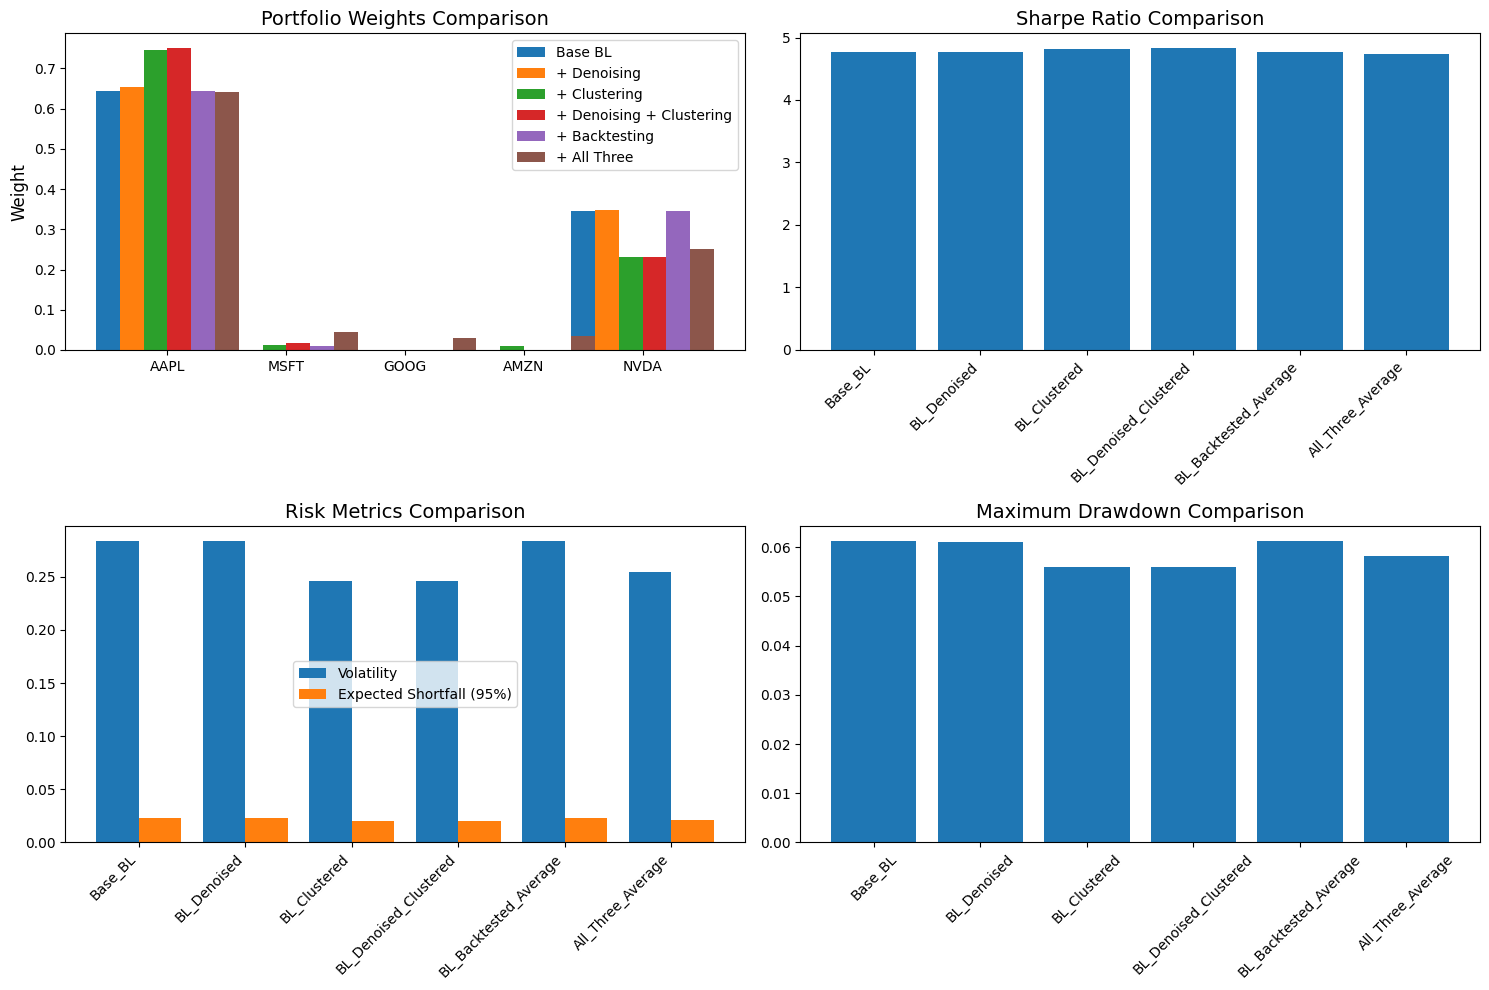

In [ ]:
# Visualization
plt.figure(figsize=(15, 10))


# Weights comparison
plt.subplot(2, 2, 1)
x = np.arange(len(tickers))
width = 0.2
plt.bar(x - 2.5*width, weights_summary['Base_BL'], width, label='Base BL')
plt.bar(x - 1.5*width, weights_summary['BL_Denoised'], width, label='+ Denoising')
plt.bar(x - 0.5*width, weights_summary['BL_Clustered'], width, label='+ Clustering')
plt.bar(x + 0.5*width, weights_summary['BL_Denoised_Clustered'], width, label='+ Denoising + Clustering')
plt.bar(x + 1.5*width, weights_summary['BL_Backtested_Average'], width, label='+ Backtesting')
plt.bar(x + 2.5*width, weights_summary['All_Three_Average'], width, label='+ All Three')

plt.xticks(x, tickers, fontsize=10)
plt.ylabel('Weight', fontsize=12)
plt.title('Portfolio Weights Comparison', fontsize=14)
plt.legend(fontsize=10)

# Sharpe ratio comparison
plt.subplot(2, 2, 2)
models = ['Base_BL', 'BL_Denoised', 'BL_Clustered','BL_Denoised_Clustered', 'BL_Backtested_Average','All_Three_Average']
sharpe_values =[train_summary.loc['Base_BL', 'Sharpe Ratio'],
                train_summary.loc['BL_Denoised', 'Sharpe Ratio'],
                train_summary.loc['BL_Clustered', 'Sharpe Ratio'],
                train_summary.loc['BL_Denoised_Clustered', 'Sharpe Ratio'],
                train_summary.loc['BL_Backtested_Average', 'Sharpe Ratio'],
                train_summary.loc['All_Three_Average', 'Sharpe Ratio']]
plt.bar(models, sharpe_values)
plt.title('Sharpe Ratio Comparison', fontsize=14)
plt.xticks(ha='right', fontsize=10, rotation=45)
plt.yticks(fontsize=10)


# Risk comparison
plt.subplot(2, 2, 3)
vol_values = [train_summary.loc['Base_BL', 'Volatility'],
             train_summary.loc['BL_Denoised', 'Volatility'],
             train_summary.loc['BL_Clustered', 'Volatility'],
             train_summary.loc['BL_Denoised_Clustered', 'Volatility'],
             train_summary.loc['BL_Backtested_Average', 'Volatility'],
             train_summary.loc['All_Three_Average', 'Volatility']

              ]

es_values = [-train_summary.loc['Base_BL', 'Expected Shortfall (95%)'],
            -train_summary.loc['BL_Denoised', 'Expected Shortfall (95%)'],
            -train_summary.loc['BL_Clustered', 'Expected Shortfall (95%)'],
            -train_summary.loc['BL_Denoised_Clustered', 'Expected Shortfall (95%)'],
            -train_summary.loc['BL_Backtested_Average', 'Expected Shortfall (95%)'],
            -train_summary.loc['All_Three_Average', 'Expected Shortfall (95%)']]
x_pos = np.arange(len(models))
plt.bar(x_pos - 0.2, vol_values, 0.4, label='Volatility')
plt.bar(x_pos + 0.2, es_values, 0.4, label='Expected Shortfall (95%)')
plt.xticks(x_pos, models,ha='right', fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.title('Risk Metrics Comparison', fontsize=14)
plt.legend(fontsize=10,loc='center')

# Drawdown comparison
plt.subplot(2, 2, 4)
dd_values = [-train_summary.loc['Base_BL', 'Max Drawdown'],
            -train_summary.loc['BL_Denoised', 'Max Drawdown'],
            -train_summary.loc['BL_Clustered', 'Max Drawdown'],
            -train_summary.loc['BL_Denoised_Clustered', 'Max Drawdown'],
            -train_summary.loc['BL_Backtested_Average', 'Max Drawdown'],
            -train_summary.loc['All_Three_Average', 'Max Drawdown']]
plt.bar(models, dd_values)
plt.title('Maximum Drawdown Comparison', fontsize=14)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Step 4
Students will run these improvements by 'training’ on the data up to the date of GWP2. Then students will ‘test’ the model on the 2 weeks of daily data between GWP2’s date and the GWP3 date. They will show how well (or poorly) each of the improvements performed out-of-sample.

In [ ]:
# Out-of-Sample Performance Test
# 1 month after EndDate (2023-06-30) used in GWP2
oos_test_prices = yf.download(tickers, start="2023-07-01", end="2023-07-30")['Close']
oos_test_returns = oos_test_prices.pct_change().dropna()

/tmp/ipython-input-3972789524.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oos_test_prices = yf.download(tickers, start="2023-07-01", end="2023-07-30")['Close']
[*********************100%***********************]  5 of 5 completed


In [ ]:
oos_test_returns.describe()

Ticker,AAPL,AMZN,GOOG,MSFT,NVDA
count,18.000000,18.000000,18.000000,18.000000,18.000000
mean,0.000994,0.000984,0.005689,0.000230,0.005622
std,0.007885,0.017250,0.021464,0.018863,0.020542
min,-0.010856,-0.039894,-0.027218,-0.037637,-0.033074
25%,-0.005886,-0.008134,-0.007510,-0.012167,-0.006964
50%,0.001648,0.001005,0.006748,0.001674,0.006086
75%,0.004537,0.012500,0.015432,0.012977,0.020992
max,0.017306,0.030877,0.055949,0.039800,0.047264


In [ ]:
'''
    'Base_BL': opt_weights_bl,
    'BL_Denoised': opt_weights_denoised,
    'BL__Clustered': opt_weights_clustered,
    'BL_Denoised_Clustered': opt_weights_denoised_clustered,
    'Backtested_Average': avg_metrics['weights']
'''

# Evaluate each portfolio
portfolio_cumulative_return_bl = portfolio_cumulative_return(opt_weights_bl, oos_test_returns)
portfolio_cumulative_return_denoised = portfolio_cumulative_return(opt_weights_denoised, oos_test_returns)
portfolio_cumulative_return_clustered = portfolio_cumulative_return(opt_weights_clustered, oos_test_returns)
portfolio_cumulative_return_denoised_clustered = portfolio_cumulative_return(opt_weights_denoised_clustered, oos_test_returns)
portfolio_cumulative_return_backtested = portfolio_cumulative_return(avg_metrics_backtested['weights'], oos_test_returns)
portfolio_cumulative_return_all_three = portfolio_cumulative_return(avg_metrics_all_three['weights'], oos_test_returns)

performance_base_bl = calculate_portfolio_performance(oos_test_returns, opt_weights_bl, rf_annual)
performance_denoised = calculate_portfolio_performance(oos_test_returns, opt_weights_denoised, rf_annual)
performance_clustered = calculate_portfolio_performance(oos_test_returns, opt_weights_clustered, rf_annual)
performance_denoised_clustered = calculate_portfolio_performance(oos_test_returns, opt_weights_denoised_clustered, rf_annual)
performance_backtested = calculate_portfolio_performance(oos_test_returns, avg_metrics_backtested['weights'], rf_annual)
performance_all_three = calculate_portfolio_performance(oos_test_returns, avg_metrics_all_three['weights'], rf_annual)

In [ ]:
# 3. Create comparison summary DataFrame
oos_summary = pd.DataFrame({
    'Cumulative Return': [
        performance_base_bl['cumulative_return'],
        performance_denoised['cumulative_return'],
        performance_clustered['cumulative_return'],
        performance_denoised_clustered['cumulative_return'],
        performance_backtested['cumulative_return'],
        performance_all_three['cumulative_return']
    ],
    'Annualised Return': [
        performance_base_bl['annualized_return'],
        performance_denoised['annualized_return'],
        performance_clustered['annualized_return'],
        performance_denoised_clustered['annualized_return'],
        performance_backtested['annualized_return'],
        performance_all_three['annualized_return']
    ],
    'Volatility': [
        performance_base_bl['annualized_volatility'],
        performance_denoised['annualized_volatility'],
        performance_clustered['annualized_volatility'],
        performance_denoised_clustered['annualized_volatility'],
        performance_backtested['annualized_volatility'],
        performance_all_three['annualized_volatility']
    ],
    'Sharpe Ratio': [
        performance_base_bl['sharpe_ratio'],
        performance_denoised['sharpe_ratio'],
        performance_clustered['sharpe_ratio'],
        performance_denoised_clustered['sharpe_ratio'],
        performance_backtested['sharpe_ratio'],
        performance_all_three['sharpe_ratio']
    ],
    'Sortino Ratio': [
        performance_base_bl['sortino_ratio'],
        performance_denoised['sortino_ratio'],
        performance_clustered['sortino_ratio'],
        performance_denoised_clustered['sortino_ratio'],
        performance_backtested['sortino_ratio'],
        performance_all_three['sortino_ratio']
    ],
    'Max Drawdown': [
        performance_base_bl['max_drawdown'],
        performance_denoised['max_drawdown'],
        performance_clustered['max_drawdown'],
        performance_denoised_clustered['max_drawdown'],
        performance_backtested['max_drawdown'],
        performance_all_three['max_drawdown']
    ],
    'Expected Shortfall (95%)': [
        performance_base_bl['expected_shortfall_95'],
        performance_denoised['expected_shortfall_95'],
        performance_clustered['expected_shortfall_95'],
        performance_denoised_clustered['expected_shortfall_95'],
        performance_backtested['expected_shortfall_95'],
        performance_all_three['expected_shortfall_95']
    ]
}, index=[
    'Base_BL',
    'BL_Denoised',
    'BL_Clustered',
    'BL_Denoised_Clustered',
    'BL_Backtested_Average',
    'All_Three_Average'
])

In [ ]:
# 4. Nicely format for display
print("Out-of-Sample 1-month Performance Comparison:")
display(oos_summary.style.format({
    'Cumulative Return': '{:.2%}',
    'Annualised Return': '{:.2%}',
    'Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.3f}',
    'Sortino Ratio': '{:.3f}',
    'Max Drawdown': '{:.2%}',
    'Expected Shortfall (95%)': '{:.2%}'
}))

Out-of-Sample 1-month Performance Comparison:


,Cumulative Return,Annualised Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Expected Shortfall (95%)
Base_BL,4.67%,89.40%,16.74%,3.688,8.571,-3.13%,-1.84%
BL_Denoised,4.68%,89.76%,16.70%,3.707,8.700,-3.11%,-1.81%
BL_Clustered,3.68%,65.91%,14.80%,3.254,7.629,-2.66%,-1.59%
BL_Denoised_Clustered,3.71%,66.44%,14.78%,3.279,7.646,-2.66%,-1.60%
BL_Backtested_Average,4.67%,89.40%,16.74%,3.688,8.571,-3.13%,-1.84%
All_Three_Average,4.08%,74.97%,15.66%,3.424,7.552,-2.87%,-1.81%


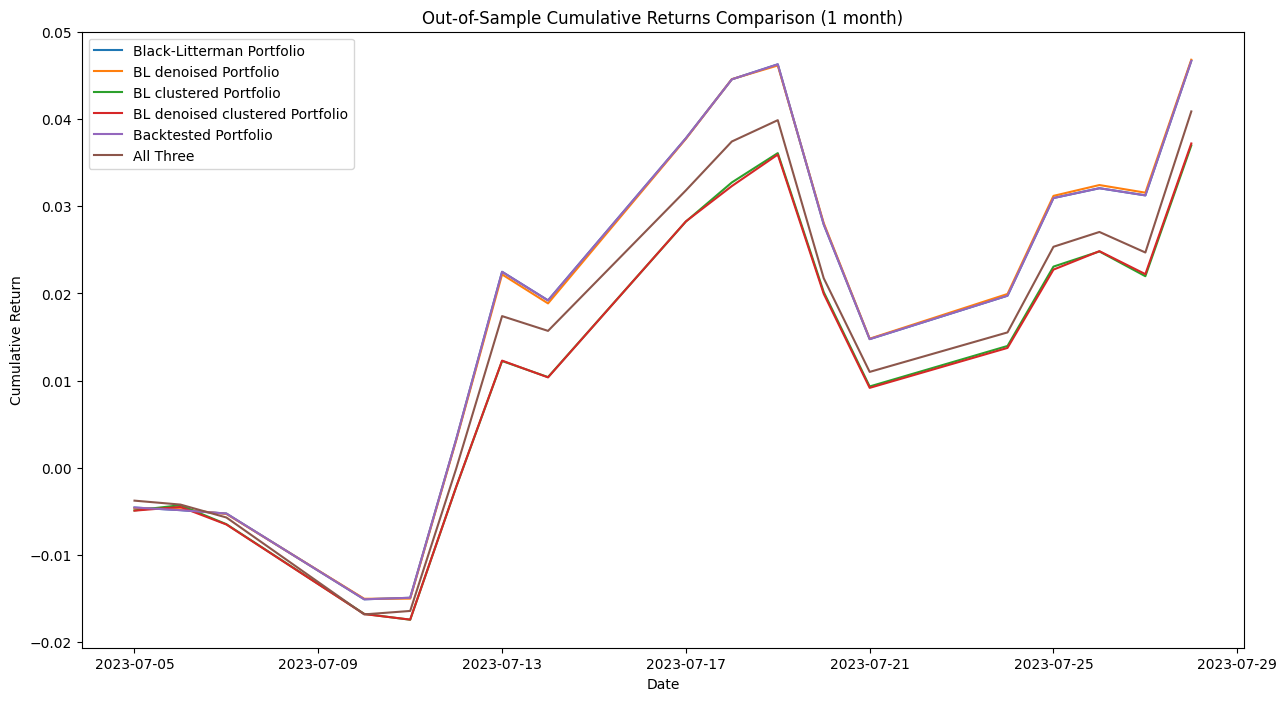

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(portfolio_cumulative_return_bl, label='Black-Litterman Portfolio')
plt.plot(portfolio_cumulative_return_denoised, label='BL denoised Portfolio')
plt.plot(portfolio_cumulative_return_clustered, label='BL clustered Portfolio')
plt.plot(portfolio_cumulative_return_denoised_clustered, label='BL denoised clustered Portfolio')
plt.plot(portfolio_cumulative_return_backtested, label='Backtested Portfolio')
plt.plot(portfolio_cumulative_return_all_three, label='All Three')
plt.title('Out-of-Sample Cumulative Returns Comparison (1 month)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()


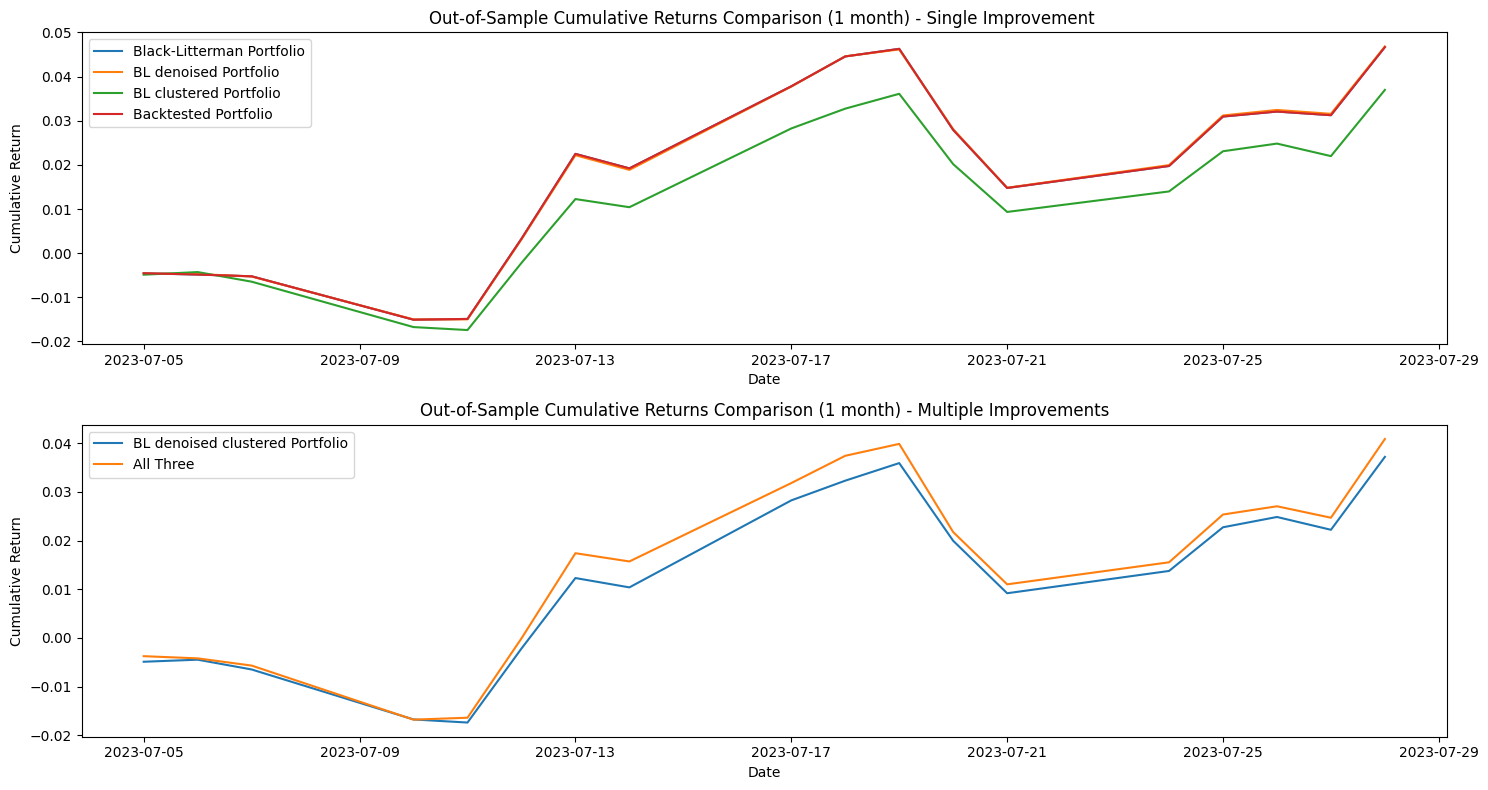

In [ ]:
plt.figure(figsize=(15, 8))

# Subplot for single improvements
plt.subplot(2, 1, 1) # 2 rows, 1 column, 1st plot
plt.plot(portfolio_cumulative_return_bl, label='Black-Litterman Portfolio')
plt.plot(portfolio_cumulative_return_denoised, label='BL denoised Portfolio')
plt.plot(portfolio_cumulative_return_clustered, label='BL clustered Portfolio')
plt.plot(portfolio_cumulative_return_backtested, label='Backtested Portfolio')
plt.title('Out-of-Sample Cumulative Returns Comparison (1 month) - Single Improvement ')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()

# Subplot for multiple improvements
plt.subplot(2, 1, 2) # 2 rows, 1 column, 2nd plot
plt.plot(portfolio_cumulative_return_denoised_clustered, label='BL denoised clustered Portfolio')
plt.plot(portfolio_cumulative_return_all_three, label='All Three')
plt.title('Out-of-Sample Cumulative Returns Comparison (1 month) - Multiple Improvements')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()

plt.tight_layout()
plt.show()